In [1]:
from src.data_model import DatasetSpec
import numpy as np

overlap = 0.7
sidelap = 0.7
height = 30.48 # 100 ft
scan_dimension_x = 150
scan_dimension_y = 150
exposure_time_ms = 2 # 1/500 exposure time
camera_angle = np.pi / 2

dataset_spec = DatasetSpec(overlap, sidelap, height, scan_dimension_x, scan_dimension_y, exposure_time_ms, camera_angle)

print(f"Nominal specs: {dataset_spec}")

Nominal specs: <src.data_model.DatasetSpec object at 0x10eba1310>


In [2]:
dataset_spec

In [3]:
from src.data_model import Camera

fx = 4938.56 # px
fy = 4936.49 # px
sensor_size_x_mm = 13.107 # single pixel size * number of pixels in X dimension
sensor_size_y_mm = 9.830 # single pixel size * number of pixels in Y dimension
num_pixels_x = 8192
num_pixels_y = 6144

camera_x10 = Camera(fx, fy, sensor_size_x_mm, sensor_size_y_mm, num_pixels_x, num_pixels_y)

print(f"X10 camera model: {camera_x10}")

X10 camera model: <src.data_model.Camera object at 0x10eba1be0>


In [4]:
from src.camera_utils import compute_focal_length_in_mm, project_world_point_to_image, compute_image_footprint_on_surface,compute_ground_sampling_distance
import numpy as np

point_3d = (25, -30, 50)
expected_xy = (2469.28, -2961.894)
xy = project_world_point_to_image(camera_x10, point_3d)

print(f"{point_3d} projected to {xy}")

assert np.allclose(xy, expected_xy, atol=1e-2)


(25, -30, 50) projected to (2469.28, -2961.894)


In [5]:
footprint_at_100m = compute_image_footprint_on_surface(camera_x10, 100)
expected_footprint_at_100m = (165.88, 124.46)

print(f"Footprint at 100m = {footprint_at_100m}")

assert np.allclose(footprint_at_100m, expected_footprint_at_100m, atol=1e-2)

Footprint at 100m = (165.8783127065379, 124.46090238205689)


In [6]:
footprint_at_200m = compute_image_footprint_on_surface(camera_x10, 200)
expected_footprint_at_200m = (165.88*2, 124.46*2)

print(f"Footprint at 200m = {footprint_at_200m}")

assert np.allclose(footprint_at_200m, expected_footprint_at_200m, atol=1e-2)

Footprint at 200m = (331.7566254130758, 248.92180476411377)


In [7]:
gsd_at_100m = compute_ground_sampling_distance(camera_x10, 100)
expected_gsd_at_100m = 0.0202

print(f"GSD at 100m: {gsd_at_100m}")

assert np.allclose(gsd_at_100m, expected_gsd_at_100m, atol=1e-4)

GSD at 100m: 0.020257308330412907


In [8]:
from src.plan_computation import *

In [9]:
computed_distances = compute_distance_between_images(camera_x10, dataset_spec)
expected_distances = np.array([15.17, 11.38], dtype=np.float32)

print(f"Computed distance for X10 camera with nominal dataset specs: {computed_distances}")

assert np.allclose(computed_distances, expected_distances, atol=1e-2)

Computed distance for X10 camera with nominal dataset specs: [15.1679125 11.380705 ]


In [10]:
import copy
camera_ = copy.copy(camera_x10)
dataset_spec_ = copy.copy(dataset_spec)

camera_.num_pixels_x = 7000
camera_.num_pixels_y = 5980
camera_.fx = 3789.45
camera_.fy = 3778.39

computed_distances_ = compute_distance_between_images(camera_, dataset_spec_)
print(f"Computed distance: {computed_distances_}")

Computed distance: [16.891106 14.472069]


In [11]:
dataset_spec.camera_angle = np.pi / 6
computed_distances = compute_distance_between_images(camera_x10, dataset_spec)
print(f"Computed distance for X10 camera with nominal dataset specs: {computed_distances}")

Computed distance for X10 camera with nominal dataset specs: [36.576    11.380705]


In [12]:
computed_speed = compute_speed_during_photo_capture(camera_x10, dataset_spec, allowed_movement_px=1)
expected_speed = 3.09

print(f"Computed speed during photo captures: {computed_speed:.2f}")

assert np.allclose(computed_speed, expected_speed, atol=1e-2)

Computed speed during photo captures: 3.09


In [13]:
camera_ = copy.copy(camera_x10)
dataset_spec_ = copy.copy(dataset_spec)

dataset_spec_.height = 50
computed_speed_ = compute_speed_during_photo_capture(camera_x10, dataset_spec_, allowed_movement_px=1)
print(f"Computed speed during photo captures: {computed_speed_:.2f}")

Computed speed during photo captures: 5.06


In [14]:
camera_.fx = 4000.45
computed_speed_ = compute_speed_during_photo_capture(camera_, dataset_spec, allowed_movement_px=1)
print(f"Computed speed during photo captures: {computed_speed_:.2f}")

Computed speed during photo captures: 3.81


In [15]:
computed_plan = generate_photo_plan_on_grid(camera_x10, dataset_spec) 

print(f"Computed plan with {len(computed_plan)} waypoints")

Computed plan with 90 waypoints


In [16]:
MAX_NUM_WAYPOINTS_TO_PRINT = 20

for idx, waypoint in enumerate(computed_plan[:MAX_NUM_WAYPOINTS_TO_PRINT]):
    print(f"Idx {idx}: {waypoint}")
if len(computed_plan) >= MAX_NUM_WAYPOINTS_TO_PRINT:
    print("...")

Idx 0: <src.data_model.Waypoint object at 0x113130820>
Idx 1: <src.data_model.Waypoint object at 0x113130d60>
Idx 2: <src.data_model.Waypoint object at 0x113130280>
Idx 3: <src.data_model.Waypoint object at 0x113130ee0>
Idx 4: <src.data_model.Waypoint object at 0x113130dc0>
Idx 5: <src.data_model.Waypoint object at 0x113130e80>
Idx 6: <src.data_model.Waypoint object at 0x113130d00>
Idx 7: <src.data_model.Waypoint object at 0x1131301f0>
Idx 8: <src.data_model.Waypoint object at 0x1131308e0>
Idx 9: <src.data_model.Waypoint object at 0x113130bb0>
Idx 10: <src.data_model.Waypoint object at 0x1131307f0>
Idx 11: <src.data_model.Waypoint object at 0x1131306a0>
Idx 12: <src.data_model.Waypoint object at 0x113130430>
Idx 13: <src.data_model.Waypoint object at 0x113131af0>
Idx 14: <src.data_model.Waypoint object at 0x113131ee0>
Idx 15: <src.data_model.Waypoint object at 0x113131bb0>
Idx 16: <src.data_model.Waypoint object at 0x113131b50>
Idx 17: <src.data_model.Waypoint object at 0x113131d60>
Id

The flight plan using the client's default values

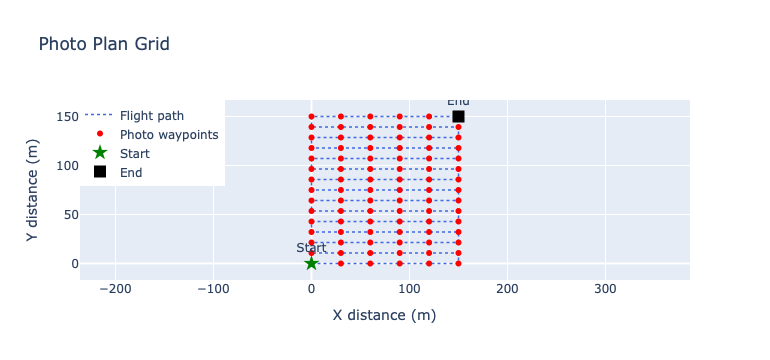

In [17]:
from src.visualization import *
fig = plot_photo_plan(computed_plan)
fig.show()

Changing the exposure time

<src.data_model.Camera object at 0x12f7ee7f0> <src.data_model.DatasetSpec object at 0x12f7ee790>


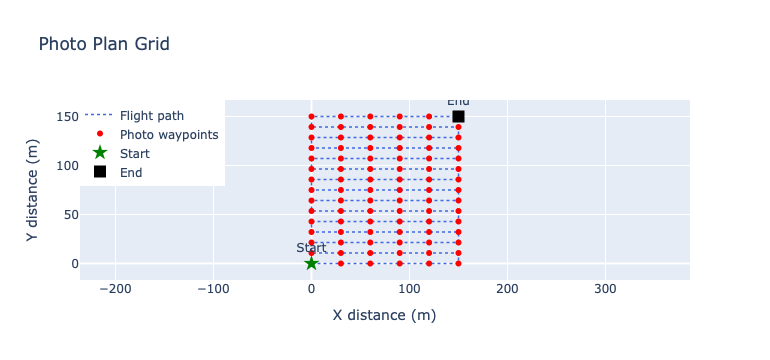

In [18]:
camera_ = copy.deepcopy(camera_x10)
dataset_spec_ = copy.deepcopy(dataset_spec)

dataset_spec_.exposure_time = 1000

print(camera_, dataset_spec_)

fig = plot_photo_plan(generate_photo_plan_on_grid(camera_, dataset_spec_))
fig.show()

Changing the height parameter

<src.data_model.Camera object at 0x12f7ee7f0> <src.data_model.DatasetSpec object at 0x12f7ee790>


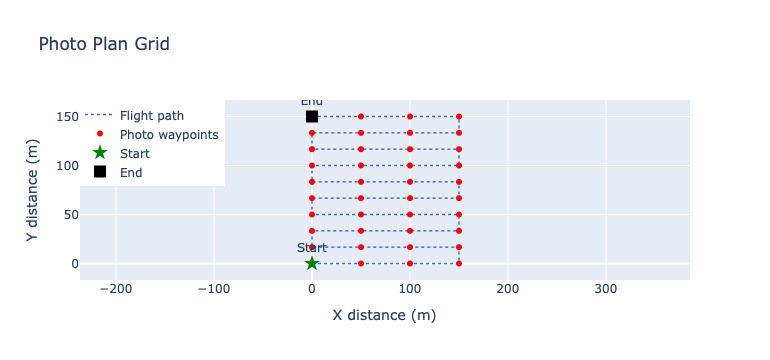

In [19]:
dataset_spec_.height = 50
print(camera_, dataset_spec_)

fig = plot_photo_plan(generate_photo_plan_on_grid(camera_, dataset_spec_))
fig.show()

Changing the overlap parameter

<src.data_model.Camera object at 0x12f7ee7f0> <src.data_model.DatasetSpec object at 0x12f7ee790>


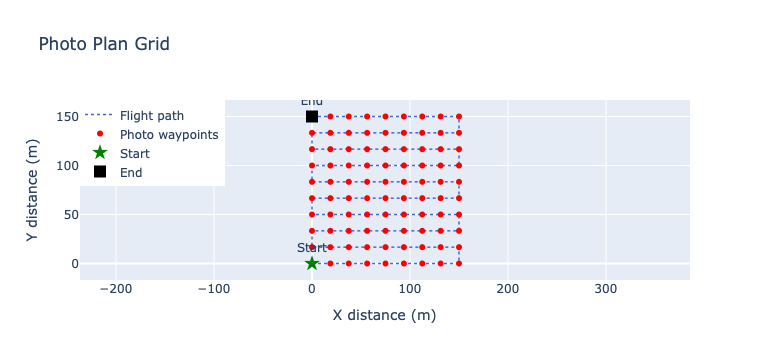

In [20]:
dataset_spec_.overlap = 0.9
print(camera_, dataset_spec_)

fig = plot_photo_plan(generate_photo_plan_on_grid(camera_, dataset_spec_))
fig.show()

Changing side lap

<src.data_model.Camera object at 0x12f7ee7f0> <src.data_model.DatasetSpec object at 0x12f7ee790>


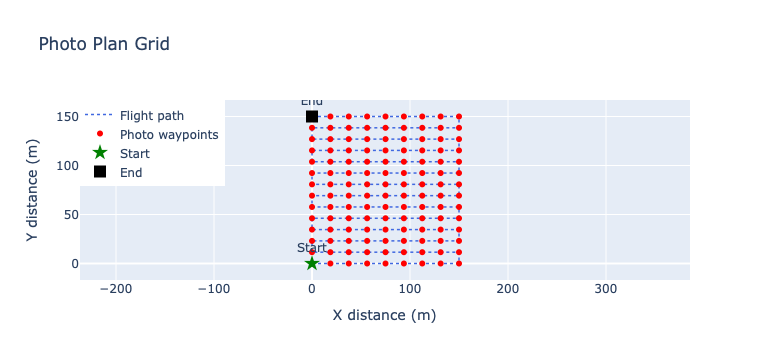

In [21]:
dataset_spec_.sidelap = 0.8
print(camera_, dataset_spec_)

fig = plot_photo_plan(generate_photo_plan_on_grid(camera_, dataset_spec_))
fig.show()

The total flight time for a grid capture mission

In [25]:
time = compute_total_time(camera_x10, dataset_spec, computed_plan)
print(time)

656.7074129883484
